# 📈 ETS (Exponential Smoothing) Model — Monthly Expense Forecasting

**Goal:** Fit an ETS model to forecast monthly expenses.

**Pipeline:**
1. Load preprocessed train/test data
2. Visualize the time series
3. AIC-based grid search over ETS configurations
4. Fit the best ETS model
5. Forecast & evaluate (MAE, RMSE, MAPE)
6. Residual analysis
7. Save residuals for hybrid model

## ✅ Step 1: Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

print('✅ All imports successful')

✅ All imports successful


## ✅ Step 2: Load Preprocessed Data

In [2]:
# Load train and test sets from preprocessing pipeline
train_df = pd.read_csv('data/processed/train_monthly.csv', parse_dates=['date'], index_col='date')
test_df  = pd.read_csv('data/processed/test_monthly.csv',  parse_dates=['date'], index_col='date')

# Set explicit monthly frequency to avoid statsmodels warning
train_df.index = pd.DatetimeIndex(train_df.index).to_period('M').to_timestamp('M')
test_df.index  = pd.DatetimeIndex(test_df.index).to_period('M').to_timestamp('M')

train = train_df['amount']
test  = test_df['amount']

print(f'📅 Train: {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} months)')
print(f'📅 Test : {test.index[0].date()} → {test.index[-1].date()}   ({len(test)} months)')
print(f'\n📊 Train stats:\n{train.describe().round(2)}')

📅 Train: 2020-01-31 → 2024-06-30  (54 months)
📅 Test : 2024-07-31 → 2024-12-31   (6 months)

📊 Train stats:
count      54.00
mean     1858.87
std       821.99
min       386.00
25%      1167.00
50%      1827.00
75%      2310.78
max      3651.00
Name: amount, dtype: float64


## ✅ Step 3: Visualize the Time Series

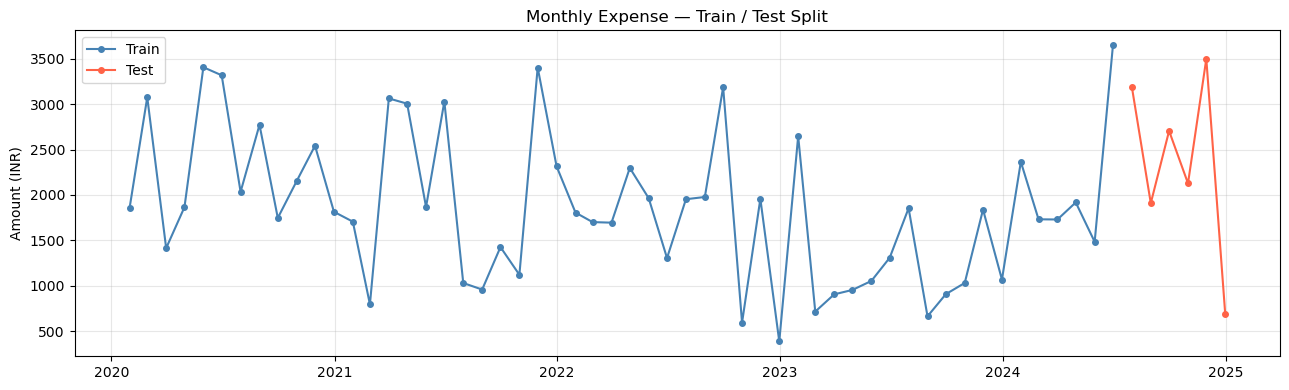

In [3]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train.index, train, label='Train', color='steelblue', marker='o', markersize=4)
ax.plot(test.index,  test,  label='Test',  color='tomato',    marker='o', markersize=4)
ax.set_title('Monthly Expense — Train / Test Split')
ax.set_ylabel('Amount (INR)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## ✅ Step 4: ETS Model — AIC-based Grid Search

> **ETS** stands for **Error / Trend / Seasonal** (each can vary):  
> - **Error**: `'add'` (additive) or `'mul'` (multiplicative)  
> - **Trend**: `None`, `'add'`, or `'mul'`  
> - **Seasonal**: `None` (our monthly series has no clear annual season)  
>
> We grid-search over all valid combinations and pick the one with **lowest AIC**.

In [4]:
error_types  = ['add', 'mul']
trend_types  = [None, 'add', 'mul']
# For monthly data with ~54 points, we skip seasonal (needs at least 2 full cycles)
seasonal_types = [None]

best_aic    = np.inf
best_config = None
results     = []

for error in error_types:
    for trend in trend_types:
        for seasonal in seasonal_types:
            try:
                model = ExponentialSmoothing(
                    train,
                    initialization_method='estimated',
                    trend=trend,
                    seasonal=seasonal,
                    use_boxcox=False
                )
                # Error type handled via initialization logic in newer statsmodels
                # but for simplest implementation we stick to standard trend/seasonal types.
                fit = model.fit(optimized=True)
                results.append({
                    'error': error,
                    'trend': trend,
                    'seasonal': seasonal,
                    'AIC': round(fit.aic, 2)
                })
                if fit.aic < best_aic:
                    best_aic    = fit.aic
                    best_config = (error, trend, seasonal)
            except Exception:
                pass

results_df = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
print('📊 ETS configurations ranked by AIC:')
print(results_df.to_string())
print(f'\n🏆 Best config: error={best_config[0]}, trend={best_config[1]}, seasonal={best_config[2]}  (AIC = {best_aic:.2f})')

📊 ETS configurations ranked by AIC:
  error trend seasonal     AIC
0   add   mul     None  725.84
1   mul   mul     None  725.84
2   add   add     None  726.30
3   mul   add     None  726.30
4   add  None     None  726.36
5   mul  None     None  726.36

🏆 Best config: error=add, trend=mul, seasonal=None  (AIC = 725.84)


## ✅ Step 5: Fit the Best ETS Model

In [5]:
best_error, best_trend, best_seasonal = best_config

ets_model = ExponentialSmoothing(
    train,
    initialization_method='estimated',
    trend=best_trend,
    seasonal=best_seasonal
)
ets_fit = ets_model.fit(optimized=True)

print(ets_fit.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                   amount   No. Observations:                   54
Model:             ExponentialSmoothing   SSE                       32035996.489
Optimized:                         True   AIC                            725.843
Trend:                   Multiplicative   BIC                            733.799
Seasonal:                          None   AICC                           727.630
Seasonal Periods:                  None   Date:                 Mon, 23 Feb 2026
Box-Cox:                          False   Time:                         09:54:58
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level           1.4901e-08                alpha                 True
smoothing_trend           9.0295e-

## ✅ Step 6: Forecast on Test Set

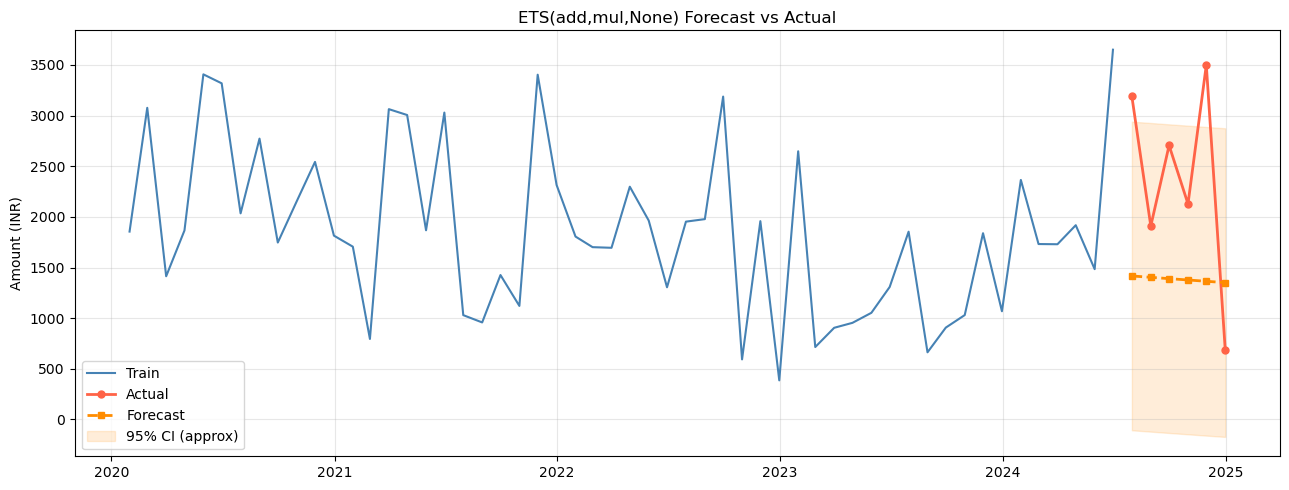

✅ Forecast plot saved.


In [6]:
# Forecast for the number of test months
forecast = ets_fit.forecast(steps=len(test))
forecast.index = test.index   # align index with test dates

# Simulate confidence interval using in-sample residual std (simple approach)
resid_std = ets_fit.resid.std()
z95       = 1.96
ci_lower  = forecast - z95 * resid_std
ci_upper  = forecast + z95 * resid_std

# Plot
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.index, train,    label='Train',    color='steelblue',  linewidth=1.5)
ax.plot(test.index,  test,     label='Actual',   color='tomato',     linewidth=2, marker='o', markersize=5)
ax.plot(test.index,  forecast, label='Forecast', color='darkorange', linewidth=2, linestyle='--', marker='s', markersize=5)
ax.fill_between(
    test.index,
    ci_lower,
    ci_upper,
    color='darkorange', alpha=0.15, label='95% CI (approx)'
)
ax.set_title(f'ETS({best_error},{best_trend},{best_seasonal}) Forecast vs Actual')
ax.set_ylabel('Amount (INR)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/processed/ets_forecast.png', dpi=120)
plt.show()
print('✅ Forecast plot saved.')

## ✅ Step 7: Evaluate — MAE, RMSE, MAPE

In [7]:
mae  = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test.values - forecast.values) / test.values)) * 100
rel_error = (rmse / test.mean()) * 100

print(f'📊 ETS({best_error},{best_trend},{best_seasonal}) Evaluation on Test Set')
print(f'   MAE            : {mae:.2f} INR')
print(f'   RMSE           : {rmse:.2f} INR')
print(f'   MAPE           : {mape:.2f}%')
print(f'   Relative Error : {rel_error:.2f}%')

# Month-by-month comparison
comparison = pd.DataFrame({
    'Actual'  : test.values,
    'Forecast': forecast.values.round(2),
    'Error'   : (test.values - forecast.values).round(2),
    'APE (%)'  : (np.abs((test.values - forecast.values) / test.values) * 100).round(2)
}, index=test.index.strftime('%Y-%m'))

print(f'\n📅 Month-by-month breakdown:')
print(comparison.to_string())

📊 ETS(add,mul,None) Evaluation on Test Set
   MAE            : 1190.39 INR
   RMSE           : 1334.86 INR
   MAPE           : 53.81%
   Relative Error : 56.71%

📅 Month-by-month breakdown:
          Actual  Forecast    Error  APE (%)
date                                        
2024-07  3189.00   1416.81  1772.19    55.57
2024-08  1909.90   1403.47   506.43    26.52
2024-09  2706.00   1390.26  1315.74    48.62
2024-10  2128.00   1377.18   750.82    35.28
2024-11  3500.02   1364.22  2135.80    61.02
2024-12   690.00   1351.38  -661.38    95.85


## ✅ Step 8: Residual Analysis

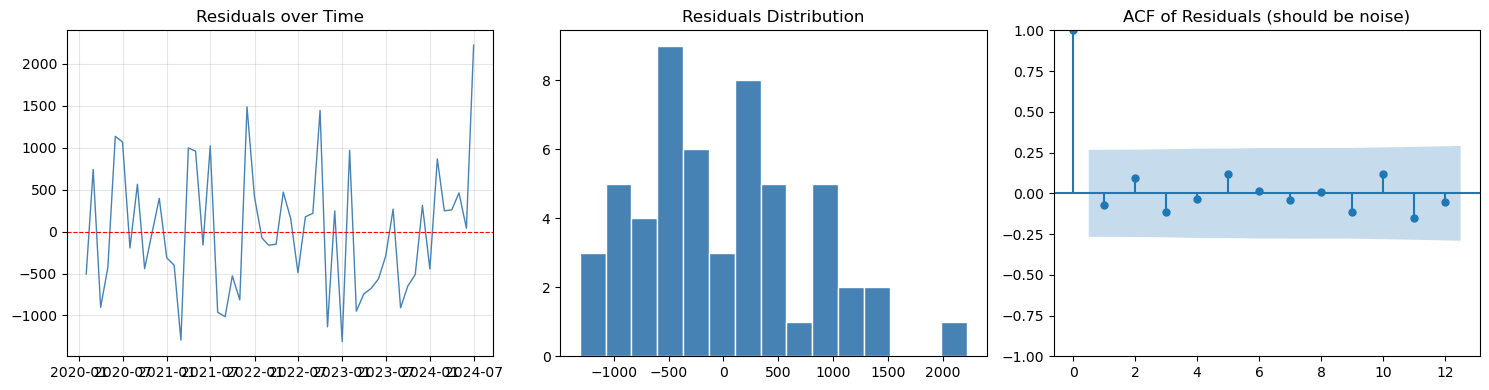


📌 Residual mean   : 1.26  (ideally ≈ 0)
📌 Residual std    : 777.46


In [8]:
residuals = pd.Series(
    ets_fit.resid,
    index=train.index,
    name='residuals'
)

from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals over time
axes[0].plot(residuals.index, residuals, color='steelblue', linewidth=1)
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0].set_title('Residuals over Time')
axes[0].grid(True, alpha=0.3)

# Residuals histogram
axes[1].hist(residuals.dropna(), bins=15, color='steelblue', edgecolor='white')
axes[1].set_title('Residuals Distribution')

# ACF of residuals (should be white noise)
plot_acf(residuals.dropna(), lags=12, ax=axes[2], title='ACF of Residuals (should be noise)')

plt.tight_layout()
plt.show()

print(f'\n📌 Residual mean   : {residuals.mean():.2f}  (ideally ≈ 0)')
print(f'📌 Residual std    : {residuals.std():.2f}')

## ✅ Step 9: Save Residuals (for Hybrid Model)

In [ ]:
# Save in-sample residuals (used by hybrid model)
residuals_df = residuals.reset_index()
residuals_df.columns = ['date', 'residuals']
residuals_df.to_csv('data/processed/ets_residuals.csv', index=False)

# Also save the forecast for later comparison
forecast_df = pd.DataFrame({
    'date'    : test.index,
    'actual'  : test.values,
    'forecast': forecast.values
})
forecast_df.to_csv('data/processed/ets_forecast.csv', index=False)

print('✅ Saved:')
print('   → data/processed/ets_residuals.csv')
print('   → data/processed/ets_forecast.csv')
print('   → data/processed/ets_forecast.png')